<a href="https://colab.research.google.com/github/sarthakpol7117-droid/neon-blaster/blob/main/codomax_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [ ]:
df.head()        # first 5 rows
df.tail()         # last 5 rows
df.shape          # (rows, columns)
df.columns        # column names
df.info()         # data types + non-null counts
df.describe()     # summary stats for numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df['Age']                    # a single column (Series)
df[['Age', 'Fare']]          # multiple columns (DataFrame)
df['Sex'].unique()           # unique values in a column
df['Pclass'].value_counts()  # count of each category

,count
Pclass,
3,491
1,216
2,184


In [ ]:
# Passengers older than 30
df[df['Age'] > 30]

# Female passengers in first class
df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]

# Passengers who survived
df[df['Survived'] == 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [ ]:
df.sort_values('Fare', ascending=False).head(10)   # 10 highest fares

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C


In [ ]:
# Average age by passenger class
df.groupby('Pclass')['Age'].mean()

# Survival rate by sex
df.groupby('Sex')['Survived'].mean()

# Multiple stats at once
df.groupby('Pclass')['Fare'].agg(['mean', 'min', 'max', 'count'])

,mean,min,max,count
Pclass,,,,
1,84.154687,0.0,512.3292,216
2,20.662183,0.0,73.5000,184
3,13.675550,0.0,69.5500,491


In [ ]:
ages = df['Age'].dropna().values   # convert a column to a NumPy array
np.mean(ages)
np.median(ages)
np.std(ages)

np.float64(14.516321150817316)

In [ ]:
df.isnull().sum()                       # missing values per column
df.isnull().sum() / len(df) * 100       # as a percentage

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
# Option A: Drop rows with any missing values (aggressive — use carefully)
df_dropped = df.dropna()

# Option B: Drop a column entirely if it's mostly missing (e.g. Cabin)
df = df.drop(columns=['Cabin'])

# Option C: Fill missing numeric values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Option D: Fill missing categorical values with the most common value (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.isnull().sum()   # should now show 0 (or close to it) for cleaned columns

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df = df.rename(columns={'Sex': 'Gender'})
df = df[['PassengerId', 'Gender', 'Age', 'Pclass', 'Fare', 'Survived', 'Embarked']]

In [ ]:
# Bucket age into groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])

df['AgeGroup'].value_counts()

,count
AgeGroup,
Adult,535
Middle-Aged,195
Teen,70
Child,69
Senior,22


In [ ]:
# Q1: What was the overall survival rate?
df['Survived'].mean()

# Q2: Did age group affect survival?
df.groupby('AgeGroup')['Survived'].mean()

# Q3: Did class + gender together affect survival?
df.groupby(['Pclass', 'Gender'])['Survived'].mean()

# Q4: Correlation between numeric variables
df[['Age', 'Fare', 'Pclass', 'Survived']].corr()

/tmp/ipykernel_1241/3976609464.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean()


,Age,Fare,Pclass,Survived
Age,1.000000,0.096688,-0.339898,-0.064910
Fare,0.096688,1.000000,-0.549500,0.257307
Pclass,-0.339898,-0.549500,1.000000,-0.338481
Survived,-0.064910,0.257307,-0.338481,1.000000


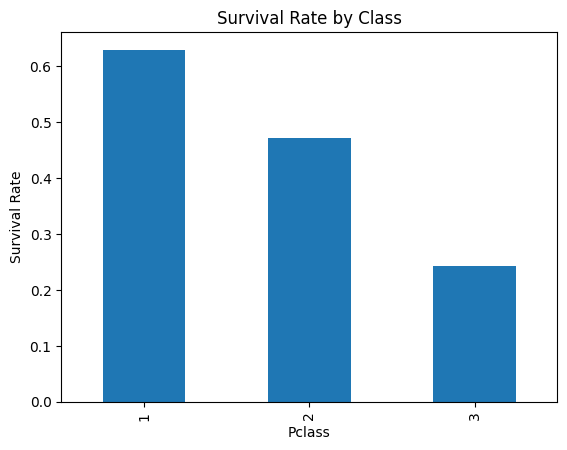

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', title='Survival Rate by Class')
plt.ylabel('Survival Rate')
plt.show()